# EXERCISE - Analysing objects in 3D
---

*Introduction to Image Analysis Workshop*

*Stefania Marcotti (stefania.marcotti@crick.ac.uk)*

*Analysing objects in 3 dimensions*

*CC-BY-SA-4.0 license: creativecommons.org/licenses/by-sa/4.0/*

*Adapted from Tom Slater (slatert2@cardiff.ac.uk)*

*[Intro to building image analysis pipelines for 3D data with Python](https://github.com/RMS-DAIM/introduction-to-image-analysis/blob/main/Scripts/Jupyter/3d_analysis.ipynb)*

---

Fill in the gaps `[...]` in the notebook and look at the Tasks as you go through to achieve the 3D analysis. Solutions are available in the Scripts folder, but please give it a good try first! Also, try not to use ChatGPT or other LLMs (but Google is allowed!).

It might be helpful to use `napari` to visualise intermediate results as you go.

## Import libraries

In [59]:
import numpy as np
import matplotlib.pyplot as plt

from scipy import ndimage as ndi

import skimage

import pandas as pd

import napari

import tqdm as notebook_tqdm

from scipy import ndimage as ndi

## Open image

We are going to use [a demo image from `skimage`](https://scikit-image.org/docs/stable/api/skimage.data.html#skimage.data.cells3d), which contains 3 dimensions and 2 channels (membrane, ch0, and nuclei, ch1). For this exercise, we are going to subset the data to only keep the nuclear channel.

In [5]:
im_all = skimage.data.cells3d()

<div style="background-color:#abd9e9; border-radius: 5px; padding: 10pt">
<strong>Task</strong>
Subset the image to only obtain the nuclear channel and load the result to a <code>napari</code> viewer window </div>

In [6]:
im_all.shape

(60, 2, 256, 256)

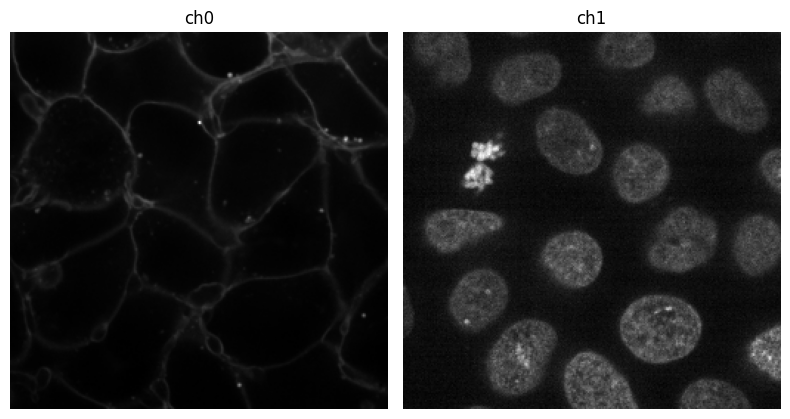

In [7]:
fig, axs = plt.subplots(1, 2, figsize=(8,6))

z = 25
axs[0].imshow(im_all[z,0,], cmap='gray')
axs[0].set_title('ch0')
axs[0].axis('off')

axs[1].imshow(im_all[z,1,], cmap='gray')
axs[1].set_title('ch1')
axs[1].axis('off')

plt.tight_layout()

#The nuclei are in channel 1

In [8]:
im_all.shape

(60, 2, 256, 256)

In [9]:
im_all_ch1 = im_all[:,1,] #THIS IS ONLY TAKING FROM CHANNEL 1

In [10]:
im_all_ch1.shape 

(60, 256, 256)

In [11]:
viewer = napari.Viewer()
viewer.add_image(im_all_ch1, name='nuclei', colormap='cyan', blending='additive')

<Image layer 'nuclei' at 0x14b090880>

## Use filters to suppress noise

<div style="background-color:#abd9e9; border-radius: 5px; padding: 10pt">
<strong>Task</strong>
Apply a Gaussian blur and load the result to a <code>napari</code> viewer window </div>

In [13]:
from skimage import filters

In [39]:
im = im_all_ch1
im_gauss = filters.gaussian(im, sigma=2)

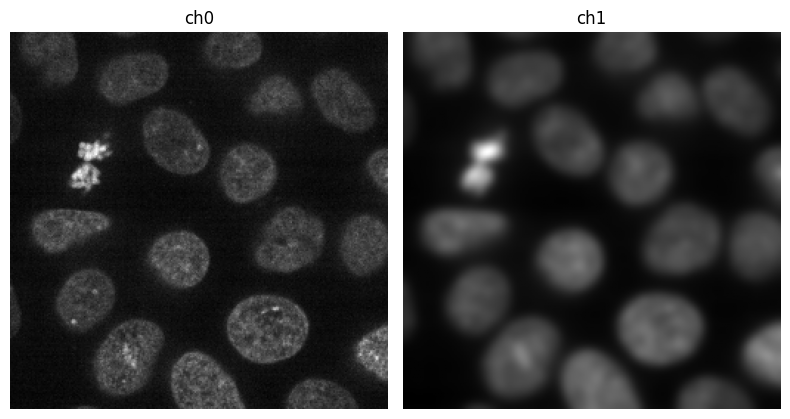

In [38]:
fig, axs = plt.subplots(1, 2, figsize=(8,6))

z = 25
axs[0].imshow(im[z,], cmap='gray')
axs[0].set_title('ch0')
axs[0].axis('off')

axs[1].imshow(im_gauss[z,], cmap='gray')
axs[1].set_title('ch1')
axs[1].axis('off')

plt.tight_layout()

In [22]:
viewer = napari.Viewer()
viewer.add_image(im_gauss, name='nuclei', colormap='magenta', blending='additive')

<Image layer 'nuclei' at 0x34021f9a0>

## Segment volumes

<div style="background-color:#abd9e9; border-radius: 5px; padding: 10pt">
<strong>Task</strong>
Segment the nuclei using one of <code>skimage</code> default algorithms and load the result to a <code>napari</code> viewer window </div>

In [29]:
from skimage import segmentation
from skimage import measure

In [30]:
thresh = filters.threshold_otsu(im_gauss)
im_thresh = im_gauss >= thresh

In [32]:
viewer.add_image(im_thresh, name='nuclei_mask', blending = 'additive')

<Labels layer 'nuclei_labels [1]' at 0x3764b10f0>

## Count objects

<div style="background-color:#abd9e9; border-radius: 5px; padding: 10pt">
<strong>Task</strong>
Create a label image from the binary mask obtained in the step above and load the result to a <code>napari</code> viewer window. How many objects are there in the image? </div>

In [33]:
labels = measure.label(im_thresh)

In [34]:
viewer.add_labels(labels, name='nuclei_labels', blending='additive')

<Labels layer 'nuclei_labels [1]' at 0x37618ace0>

In [36]:
print(f'The number of nuclei in the image is {labels.max()}')

The number of nuclei in the image is 23


<div style="background-color:#c1c3d7; border-radius: 5px; padding: 10pt"><strong>Task (difficult!)</strong> We might be able to improve the quality of the segmentation with seeded watershedding. Give it a go and load the results to a <code>napari</code> viewer window. How many objects are there in the image, if we use this approach?</div>

In [60]:
#Pending..

## Perform morphological quantification

<div style="background-color:#abd9e9; border-radius: 5px; padding: 10pt">
<strong>Task</strong>
Measure the volume and locate the centroid of each nucleus. Save the results in a pandas dataframe and plot the distribution of volumes in a histogram. </div>

In [40]:
props = measure.regionprops_table(labels, properties=['label', 'area', 'centroid'])
props_df = pd.DataFrame(props)

props_df.head()

,label,area,centroid-0,centroid-1,centroid-2
0,1,38750.0,39.419665,87.183768,53.560000
1,2,24646.0,33.413008,219.709649,244.457032
2,3,190766.0,34.442872,195.369164,76.056462
3,4,44426.0,34.303606,157.436028,110.758745
4,5,50869.0,31.424856,201.488117,173.486465


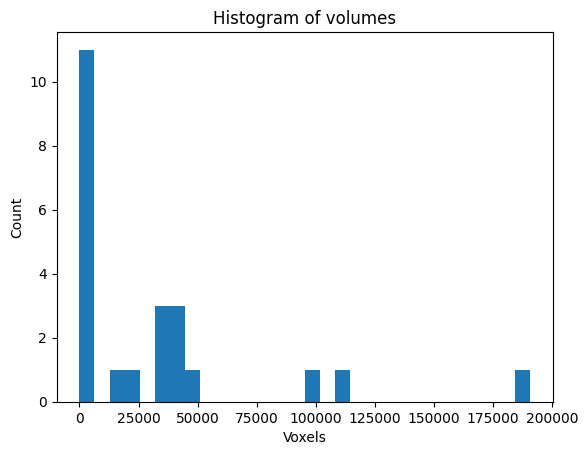

In [58]:
plt.hist(props_df['area'], bins=30)
plt.title('Histogram of volumes')
plt.xlabel('Voxels')
plt.ylabel('Count')
plt.show()